(sec:dimer-case3-g1)=
# First-order fringes

## First-order coherence function

In {numref}`sec:openqm-qme-cluster` the position-dependent coherence functions are defined. FOr a dimer, the electric field at the position of a detector far from the emitter is given by

$$
\mathbf{E}^{(+)}_{s}(\mathbf{R},t_{R}) \approx  - \hat{\mathbf{e}}_{R} \frac{\omega_{0}^{2}d}{c^2} \left [ 1 - \left(\hat{\mathbf{d}}\cdot\hat{\mathbf{R}}\right)^2\right]^{1/2} \left[ e^{- i k_{L} \hat{\mathbf{R}} \cdot \mathbf{r}_{1}} \sigma^{-}_{1}(t)+  e^{- i k_{L} \hat{\mathbf{R}} \cdot \mathbf{r}_{2}} \sigma^{-}_{2}(t) \right]
$$(eq:source_field_2)

In order to investigate interference fringes obtained by Eichmann _et al._ {cite:p}`Eichmann1993`, we calculate the first-order correlation function

$$
\begin{align}
G^{(1)}(\mathbf{R}) &= \langle \mathbf{E}^{(-)}_{s}(\mathbf{R},t_{R}) \cdot \mathbf{E}^{(+)}_{s}(\mathbf{R},t_{R})\rangle_{ss} \\
&= \left(\frac{\omega_{0}^{2}d}{c^2}\right)^2 \left [ 1 - \left(\hat{\mathbf{d}}\cdot\hat{\mathbf{R}}\right)^2\right] \sum_{ij} e^{i k_L \hat{\mathbf{R}}\cdot \mathbf{r}_{ij}} \langle\sigma^{+}_{i}\sigma^{-}_{j}\rangle_{ss} \\
& = \left(\frac{\omega_{0}^{2}d}{c^2}\right)^2 \left [ 1 - \left(\hat{\mathbf{d}}\cdot\hat{\mathbf{R}}\right)^2\right] \left[1 + \cos \theta(\mathbf{R})\right] \left(\rho_{ee}+\rho_{ss}\right) + \left[1 - \cos \theta(\mathbf{R})\right] \left(\rho_{ee}+\rho_{aa}\right)
\end{align}
$$(eq:dimer-case2-G1)

with $\theta(\mathbf{R}) = k_{L}(\hat{\mathbf{R}}_{L} - \hat{\mathbf{R}})\cdot\mathbf{r}_{12} = (\mathbf{k}_\text{in} - \mathbf{k}_\text{out})\cdot \mathbf{r}_{12}$ where $\hat{\mathbf{R}}_{L}$ is the unit vector in the direction of laser beam, and $\mathbf{k}_\text{in}$ and $\mathbf{k}_\text{out}$ are the wave vector of incoming and outgoing light.  Here we used the theoretical results {cite:p}`Skornia2001`

$$
\langle \sigma^{+}_{j}\sigma^{-}_{j}\rangle_{ss} = \rho_{ee} + \frac{1}{2}(\rho_{ss}+\rho_{aa}), \qquad \langle \sigma^{+}_{1} \sigma^{-}_{2}\rangle_{ss} = \frac{1}{2} e^{2 i \phi} (\rho_{ss}-\rho_{aa}).
$$(eq:dimer-case2-cross-correlation)

Equation {eq]`eq:dimer-case2-G1` indicates that as the measurement point moves,  the direction of $\mathbf{R}$ with respect to $\mathbf{r}_{12}$ and $\mathbf{d}$ changes.  The former determines the interference fringes and its envelope curve comes from the latter. 

Skornai _et al._ were able to derive an anlytical expression from Eq. {eq}`eq:dimer-case2-G1`, which is

$$
G^{(1)}(\mathbf{R}) = \left[1+ \cos(\theta(\mathbf{R})\right]\left[\rho_{ss} + \rho_{ss}\right]+
\left[1- \cos(\theta(\mathbf{R})\right]\left[\rho_{ss} + \rho_{aa}\right]
$$

We note that fringes by channel 1 are inverse of those by channel 2.  When two channels have the same intensity, that is $\rho_{ss} = \rho_{aa}$, $\cos\theta(\mathbf{R})$ is canceled and no fringe is formed.  In other words, the interference is generated by the dominance of channel 1 over channel 2. (See {numref}`fig:dimer-transition-diagram-2`.)

## Steady state

First, we calculate the steady state density matrix. When we solve quantum master equations, we always use the standard product states are basis set.  Then, we change the basis set afterward. The following code computes the steady state density and calculate the density matrix in the Skornia basis {eq}`eq:skornia_basis`. 

The numerical results agree perfectly with the theoretical result {eq}`eq:rho_in_Skornia_basis`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# Parameters
Delta = 0.0   # detuning
gamma0 = 0.1  # spontaneous emission rate 
Omega = 0.8*gamma0

phi = np.pi/4

i2 = qeye(2)
sz = [tensor(sigmaz(),i2),tensor(i2,sigmaz())]
sp = [tensor(sigmap(),i2),tensor(i2,sigmap())]
sm = [tensor(sigmam(),i2),tensor(i2,sigmam())]
ep = np.exp( 1j*phi)
em = np.exp(-1j*phi)

# Hamiltonian
H = 0.5*Delta*(sz[0]+sz[1]) + 0.5*Omega*(ep*sp[0]+em*sm[0]+em*sp[1]+ep*sm[1])

# Collapse operators
c_ops = [np.sqrt(gamma0)*sm[0], np.sqrt(gamma0)*sm[1]]

# Steady state
rho = steadystate(H,c_ops)

# product basis
u=[]
u.append(tensor(basis(2,0),basis(2,0)))
u.append(tensor(basis(2,1),basis(2,0)))
u.append(tensor(basis(2,0),basis(2,1)))
u.append(tensor(basis(2,1),basis(2,1)))

# Skornia basis
v=[]
v.append(u[0])
v.append((ep*u[1]+em*u[2])/np.sqrt(2))
v.append((ep*u[1]-em*u[2])/np.sqrt(2))
v.append(u[3])

# change of the basis set_
rho_s = np.zeros((4, 4), dtype=complex)
for i in range(4):
    for j in range(4):
        rho_s[[i],[j]] = rho_p.matrix_element(v[i],v[j])

# theoretical values (Skornia2001)
p_gg = (gamma0**2+Omega**2)**2/(gamma0**2+2*Omega**2)**2
p_ss = Omega**2*(2*gamma0**2+Omega**2)/(gamma0**2+2*Omega**2)**2
p_aa = Omega**4/(gamma0**2+2*Omega**2)**2
p_ee = p_aa

print("** Diagonal elements of density operator **")
print("       numerical   theory")
print("ρ_gg  = {0:7.4f}   {1:7.4f}".format(rho_s[0,0].real, p_ee))
print("ρ_ss  = {0:7.4f}   {1:7.4f}".format(rho_s[1,1].real, p_ss))
print("ρ_aa  = {0:7.4f}   {1:7.4f}".format(rho_s[2,2].real, p_aa))
print("ρ_ee  = {0:7.4f}   {1:7.4f}".format(rho_s[3,3].real, p_gg))


NameError: name 'rho_p' is not defined

## Cross correlation 

Next, we check if the two QDs are coherent. We just calculate the cross correlation $\langle\sigma^{+}_{1} \sigma^{-}_{2}\rangle$.  If this correlation does not vanish, then the two QDs are coherent.  The theoretical prediction {eq}`eq:dimer-case2-cross-correlation` indicates they are correlated.

Indeed, the numerical result shows that it is not zero. As theory predicted, the correlation does not depend on the choice of $\phi$. The present numerical results agree with the theoretical values. 

In [78]:
# theoretical value
c11_th=r_ee + 0.5*(r_ss+r_aa)
c12_th=0.5*ep**2*(r_ss-r_aa)
# numerical value
c11_nu = expect(sp[0]*sm[0],rho)
c12_nu = expect(sp[1]*sm[0],rho)
print("                        numerical        theory")
print("<sigmap_1 sigmam_1> = {0:6.4f}  {1:14.4f}".format(c11_nu,c11_th.real))
print("<sigmap_1 sigmam_2> = {0:7.4f}  {1:7.4f}".format(c12_nu,c12_th))

                        numerical        theory
<sigmap_1 sigmam_1> = 0.2807          0.2807
<sigmap_1 sigmam_2> = 0.0000+0.1231j  0.0000+0.1231j


## First-order interference fringes

Interference fringes $|G^{(1)}(\mathbf{R})|$ is computed using the quantum master equation and plotted for three different strength of the driving.  Agreement with the theory is perfect.  AS the driving strength increases, the contrast of the fringes also increases.

In the analytical expression, the location of the detector is specified by just a single parameter $\theta(\mathbf{R})$.  However, the original definition contains two parameters $\phi =  \frac{1}{2} \mathbf{k}_{L} \cdot \mathbf{r}_{12}$ and $\chi(\mathbf{R}) = k_L \hat{\mathbf{R}}\cdot \mathbf{r}_{12}$. At the end, they are combined as $\theta(\mathbf{R}) = \chi(\mathbf{R}) - 2 \phi$.  During the numerical calculation, we need to specify the location through $\chi(\mathbf{R})$.  In other words, we need to specify $\phi$ and $\chi(\mathbf{R})$.



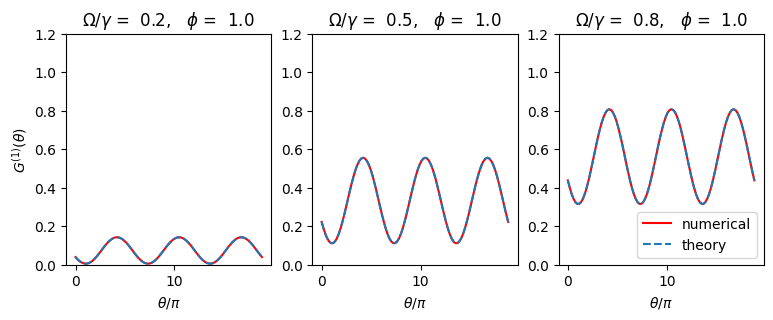

In [84]:
# we evaluate G1 measured at a single point.
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# set parameters
Delta = 0
gamma0 = 0.1

# set position parameters
phi = np.pi/3
theta = np.linspace(0,6*np.pi,100)
chi = theta - 2*phi

# collapse operators
c_ops = [np.sqrt(gamma0)*sm[0], np.sqrt(gamma0)*sm[1]]

def fringe_nu(phi,Omega):
    ep = np.exp(+1j*phi)
    em = np.exp(-1j*phi)
    H = 0.5*Delta*(sz[0]+sz[1]) + 0.5*Omega*(ep*sp[0]+em*sm[0]+em*sp[1]+ep*sm[1])
    rho=steadystate(H,c_ops)
    G1 =  np.exp(1j*chi)*(sp[0]*sm[1]*rho).tr() + np.exp(-1j*chi)*(sp[1]*sm[0]*rho).tr() + (sp[0]*sm[0]*rho+sp[1]*sm[1]*rho).tr()
    return G1

def fringe_th(phi,Omega):
    p_gg = (gamma0**2+Omega**2)**2/(gamma0**2+2*Omega**2)**2
    p_ss = Omega**2*(2*gamma0**2+Omega**2)/(gamma0**2+2*Omega**2)**2
    p_aa = Omega**4/(gamma0**2+2*Omega**2)**2
    p_ee = p_aa
    theta = 2*phi-chi
    G1 = (1+np.cos(theta))*(p_ee+p_ss)+(1-np.cos(theta))*(p_ee+p_aa)
    return G1

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
Omega=0.2*gamma0
plt.title(r"$\Omega/\gamma$" + f" = {Omega/gamma0: .1f}" + r",   $\phi$" + f" = {phi: .1f}"  )
G1_nu = fringe_nu(phi,Omega)
G1_th = fringe_th(phi,Omega)
plt.plot(theta,abs(G1_nu),color="r")
plt.plot(theta,abs(G1_th),ls='--')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$G^{(1)}(\theta)$")
plt.ylim([0.0,1.2])

plt.subplot(1,3,2)
Omega=0.5*gamma0
G1_nu = fringe_nu(phi,Omega)
G1_th = fringe_th(phi,Omega)
plt.title(r"$\Omega/\gamma$" + f" = {Omega/gamma0: .1f}" + r",   $\phi$" + f" = {phi: .1f}"  )
plt.xlabel(r"$\theta/\pi$")
plt.ylim([0.0,1.2])
plt.plot(theta,abs(G1_nu),color="r")
plt.plot(theta,abs(G1_th),ls='--')

plt.subplot(1,3,3)
Omega=0.8*gamma0
G1_nu = fringe_nu(phi,Omega)
G1_th = fringe_th(phi,Omega)
plt.title(r"$\Omega/\gamma$" + f" = {Omega/gamma0: .1f}" + r",   $\phi$" + f" = {phi: .1f}"  )
plt.xlabel(r"$\theta/\pi$")
plt.ylim([0.0,1.2])
plt.plot(theta,abs(G1_nu),color="r",label="numerical")
plt.plot(theta,abs(G1_th),ls='--',label="theory")
plt.legend(loc=4)
plt.show()